In [1]:
# Library imports
import polars as pl
import os
import dill as pickle
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load position info
video_df = pl.read_csv(r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\full_video_dataframe.csv")
homie_path = r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\homings\homings_obj.pkl"
with open(homie_path, "rb") as dill_file:
    homings = pickle.load(dill_file)
frame_by_cluster_matrix = np.load(r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\frame_by_synthetic_cluster_matrix.npy")
video_and_spike_data = pl.read_parquet(r"E:\efizz\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\processed_data\synthetic_video_spike_count_df")

In [3]:
print(frame_by_cluster_matrix)
print(frame_by_cluster_matrix.shape)
print(video_df.shape)
print(video_df.columns)

[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [30. 20.  0. ... 10.  0.  0.]
 [30. 20.  0. ... 10.  0.  0.]
 [10. 20.  0. ...  0.  0.  0.]]
(731210, 148)
(731210, 177)
['frames', 'hdir', 'mouse_x_position', 'mouse_y_position', 'OutofshelterIdx', 'EscapePeriod', 'shelter', 'barrier_present', 'barrier_flipped', 'hsa', 'h_bar_north_a', 'h_bar_south_a', 'h_bar_centre_a', 'head_randP_0', 'head_randP_1', 'head_randP_2', 'head_randP_3', 'head_randP_4', 'head_randP_5', 'head_randP_6', 'head_randP_7', 'head_randP_8', 'head_randP_9', 'head_randP_10', 'head_randP_11', 'head_randP_12', 'head_randP_13', 'head_randP_14', 'head_randP_15', 'head_randP_16', 'head_randP_17', 'head_randP_18', 'head_randP_19', 'head_randP_20', 'head_randP_21', 'head_randP_22', 'head_randP_23', 'head_randP_24', 'head_randP_25', 'head_randP_26', 'head_randP_27', 'head_randP_28', 'head_randP_29', 'head_randP_30', 'head_randP_31', 'head_randP_32', 'head_randP_33', 'head_rand

In [4]:
# Because of memory constraints, let's only keep the columns we need for this module
COLUMNS_TO_KEEP = [
    "frames",
    "mouse_x_position",
    "mouse_y_position",
    "OutofshelterIdx",
    "EscapePeriod",
    "shelter",
    "barrier_present",
    "barrier_flipped",
    'hsa', 
    'h_bar_north_a', 
    'h_bar_south_a',
]

# Select time 

In [5]:
video_df = video_df.select(COLUMNS_TO_KEEP)  # Prevents memory issues and computer crashes
# video_df = video_df.filter((video_df["barrier_present"] == True) & (video_df["barrier_flipped"] == False))
print(video_df)

shape: (731210, 11)
┌────────┬────────────┬────────────┬────────────┬─────┬────────────┬───────────┬────────────┬────────────┐
│ frames ┆ mouse_x_po ┆ mouse_y_po ┆ Outofshelt ┆ ... ┆ barrier_fl ┆ hsa       ┆ h_bar_nort ┆ h_bar_sout │
│ ---    ┆ sition     ┆ sition     ┆ erIdx      ┆     ┆ ipped      ┆ ---       ┆ h_a        ┆ h_a        │
│ i64    ┆ ---        ┆ ---        ┆ ---        ┆     ┆ ---        ┆ f64       ┆ ---        ┆ ---        │
│        ┆ f64        ┆ f64        ┆ bool       ┆     ┆ bool       ┆           ┆ f64        ┆ f64        │
╞════════╪════════════╪════════════╪════════════╪═════╪════════════╪═══════════╪════════════╪════════════╡
│ 1      ┆ 282.676091 ┆ 245.210752 ┆ true       ┆ ... ┆ false      ┆ -2.340929 ┆ -2.884015  ┆ -1.619578  │
│ 2      ┆ 282.707823 ┆ 245.301877 ┆ true       ┆ ... ┆ false      ┆ -2.332812 ┆ -2.876004  ┆ -1.611392  │
│ 3      ┆ 282.735861 ┆ 245.385096 ┆ true       ┆ ... ┆ false      ┆ -2.32511  ┆ -2.868389  ┆ -1.603632  │
│ 4      ┆ 282.75

In [6]:
homings

Homings(onset_frames=array([  4108,   5654,   8076,  12526,  22031,  32195,  91387, 178835,
       186168, 199327, 215381, 226984, 227477, 233443, 250382, 252986,
       257096, 264627, 273068, 274141, 276598, 283644, 292209, 298491,
       305840, 318433, 338493, 353811, 355863, 402838, 405147, 424174,
       428541, 431736, 437104, 441819, 458904, 462068, 462614, 471272,
       472361, 479541, 505543, 513344, 514803, 527026, 533844, 543813,
       545793, 547275, 579539, 581019, 606157, 614156, 621649, 622549,
       626447, 627397, 629064, 630015, 634170, 634915, 637122, 639039,
       640877, 649221, 650732, 663450, 674746, 675652, 678869, 681067,
       683956, 684933, 686403, 690210, 692324, 696341, 697489, 705495,
       713193, 715409, 726203], dtype=int64), offset_frames=array([  4191,   5792,   8194,  12608,  22095,  32308,  91467, 178993,
       186329, 199458, 215466, 227101, 227583, 233526, 250493, 253103,
       257211, 264733, 273133, 274216, 276718, 283718, 292315, 2986

In [7]:
onset_frames = homings.onset_frames

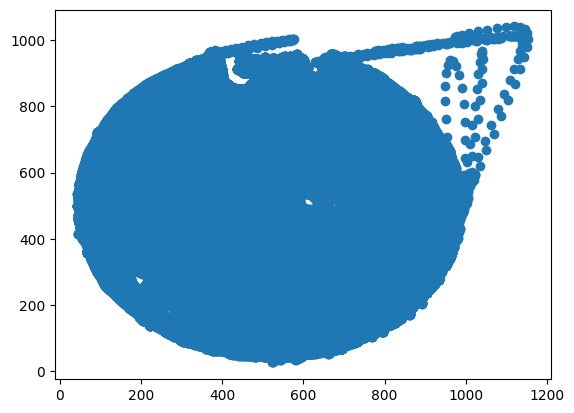

In [8]:
plt.scatter(video_df["mouse_x_position"], video_df["mouse_y_position"])

## A function to check the attributes required from the homing object exsists and to put them into a neat dictionary

In [9]:
def access_homing_attributes(homings_obj: object) -> dict:
    """Return a dictionary of verified homing attributes"""
    try:
        onset_frames = homings_obj.onset_frames
        offset_frames = homings_obj.offset_frames
    except AttributeError:
        raise AttributeError("The homings object does not have the required attributes - Something upstream is wrong with the homings object")
    assert len(onset_frames) == len(offset_frames), "The onset and offset frames are not the same length - Something is wrong with the homings object"
    return {"onset_frames": onset_frames, "offset_frames": offset_frames}

In [10]:
dic = access_homing_attributes(homings)
print(dic)
print(len(dic["onset_frames"]))

{'onset_frames': array([  4108,   5654,   8076,  12526,  22031,  32195,  91387, 178835,
       186168, 199327, 215381, 226984, 227477, 233443, 250382, 252986,
       257096, 264627, 273068, 274141, 276598, 283644, 292209, 298491,
       305840, 318433, 338493, 353811, 355863, 402838, 405147, 424174,
       428541, 431736, 437104, 441819, 458904, 462068, 462614, 471272,
       472361, 479541, 505543, 513344, 514803, 527026, 533844, 543813,
       545793, 547275, 579539, 581019, 606157, 614156, 621649, 622549,
       626447, 627397, 629064, 630015, 634170, 634915, 637122, 639039,
       640877, 649221, 650732, 663450, 674746, 675652, 678869, 681067,
       683956, 684933, 686403, 690210, 692324, 696341, 697489, 705495,
       713193, 715409, 726203], dtype=int64), 'offset_frames': array([  4191,   5792,   8194,  12608,  22095,  32308,  91467, 178993,
       186329, 199458, 215466, 227101, 227583, 233526, 250493, 253103,
       257211, 264733, 273133, 274216, 276718, 283718, 292315, 29862

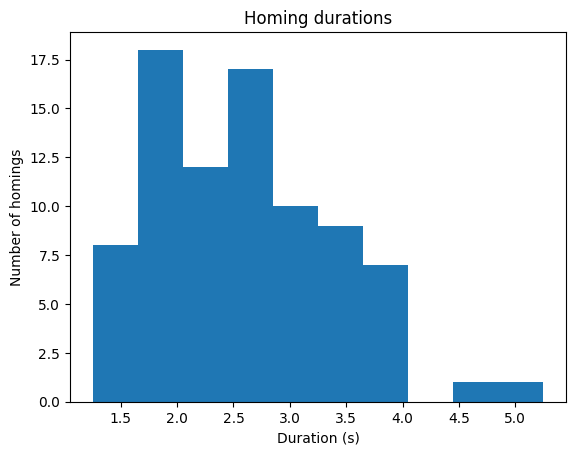

In [11]:
def plot_homing_durations(homings_dic) -> None:
    """Plot the durations of homings"""
    onset_frames = homings_dic["onset_frames"]
    offset_frames = homings_dic["offset_frames"]
    durations = (offset_frames - onset_frames) / 40 # 40 fps
    plt.hist(durations)
    plt.xlabel("Duration (s)")
    plt.ylabel("Number of homings")
    plt.title("Homing durations")
    plt.show()
plot_homing_durations(dic)

In [12]:
def check_frames_increment_by_one(arr):
    """A test to check that frames increment by 1 and as such is continuous ensuring no frames are skipped"""
    # Check each element to see if it increments by 1
    for i in range(len(arr) - 1):
        if arr[i + 1] - arr[i] != 1:
            return False
    return True

### Create some distance  bins 

[  0.         114.28571429 228.57142857 342.85714286 457.14285714
 571.42857143 685.71428571 800.        ]


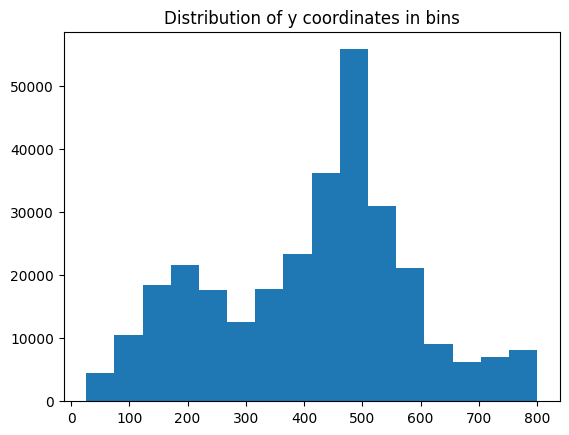

In [13]:
ycoords = video_df["mouse_y_position"]
# plt.hist(ycoords, bins=16)
# now remove y coordinats greater than 800
ycoords = ycoords.filter(ycoords < 800)
plt.hist(ycoords, bins=16)
plt.title("Distribution of y coordinates in bins")
# 8 bins would be 10cm each, so 16 bins would be 5cm each
bins = np.linspace(0, 800, 8) # Remove near shelter as there are a lot of frames there
print(bins)
# NOTE there seems to be more frames around the subgoal probably due to the turn, so we should
# probably sample the frames more uniformly across bins depending on how we want to analyse the data

In [14]:
def extract_homing_info(dic, video_df):
    """Extract homing info from video_df"""
    onset_frames = dic["onset_frames"]
    offset_frames = dic["offset_frames"]
    homing_info = []
    for onset, offset in zip(onset_frames, offset_frames):
        homing = video_df[onset:offset]
        homing_bin_idx = np.digitize(homing["mouse_y_position"], bins)
        new_column = pl.Series("bin_idx", homing_bin_idx)
        homing = homing.with_column(new_column)
        # select few columns
        homing = homing.select(["frames", "mouse_x_position", "mouse_y_position", "bin_idx",  'hsa', 'h_bar_north_a', 'h_bar_south_a',])
        homing_info.append(homing)
        
    # Check the frame column of each homing information increments uniformly by 1 such that no frames are missed
    for homing in homing_info:
        assert check_frames_increment_by_one(homing["frames"].to_numpy()), "Frames are missing in the homing information"
    
    return homing_info
info = extract_homing_info(dic, video_df)
print(info[3])

shape: (82, 7)
┌────────┬─────────────────┬─────────────────┬─────────┬───────────┬───────────────┬───────────────┐
│ frames ┆ mouse_x_positio ┆ mouse_y_positio ┆ bin_idx ┆ hsa       ┆ h_bar_north_a ┆ h_bar_south_a │
│ ---    ┆ n               ┆ n               ┆ ---     ┆ ---       ┆ ---           ┆ ---           │
│ i64    ┆ ---             ┆ ---             ┆ i64     ┆ f64       ┆ f64           ┆ f64           │
│        ┆ f64             ┆ f64             ┆         ┆           ┆               ┆               │
╞════════╪═════════════════╪═════════════════╪═════════╪═══════════╪═══════════════╪═══════════════╡
│ 12527  ┆ 866.017856      ┆ 227.719817      ┆ 2       ┆ 2.624716  ┆ 1.96584       ┆ 2.876886      │
│ 12528  ┆ 865.81501       ┆ 228.097034      ┆ 2       ┆ 2.567671  ┆ 1.908143      ┆ 2.821232      │
│ 12529  ┆ 865.581416      ┆ 228.560205      ┆ 2       ┆ 2.509928  ┆ 1.849622      ┆ 2.765109      │
│ 12530  ┆ 865.333292      ┆ 229.14716       ┆ 3       ┆ 2.453135  ┆ 1.79189

C:\Users\laurence\AppData\Local\Temp\ipykernel_32596\532869281.py:10: DeprecationWarning: `DataFrame.with_column` has been renamed; this redirect is temporary, please use `.with_columns` instead
  homing = homing.with_column(new_column)


shape: (109, 7)
┌────────┬─────────────────┬─────────────────┬─────────┬───────────┬───────────────┬───────────────┐
│ frames ┆ mouse_x_positio ┆ mouse_y_positio ┆ bin_idx ┆ hsa       ┆ h_bar_north_a ┆ h_bar_south_a │
│ ---    ┆ n               ┆ n               ┆ ---     ┆ ---       ┆ ---           ┆ ---           │
│ i64    ┆ ---             ┆ ---             ┆ i64     ┆ f64       ┆ f64           ┆ f64           │
│        ┆ f64             ┆ f64             ┆         ┆           ┆               ┆               │
╞════════╪═════════════════╪═════════════════╪═════════╪═══════════╪═══════════════╪═══════════════╡
│ 437105 ┆ 545.473205      ┆ 97.314552       ┆ 1       ┆ -2.841595 ┆ 2.846737      ┆ -2.29099      │
│ 437106 ┆ 545.226088      ┆ 96.851737       ┆ 1       ┆ -2.817909 ┆ 2.870676      ┆ -2.267845     │
│ 437107 ┆ 544.985976      ┆ 97.119383       ┆ 1       ┆ -2.792178 ┆ 2.895581      ┆ -2.241672     │
│ 437108 ┆ 544.826798      ┆ 98.292549       ┆ 1       ┆ -2.761971 ┆ 2.9235

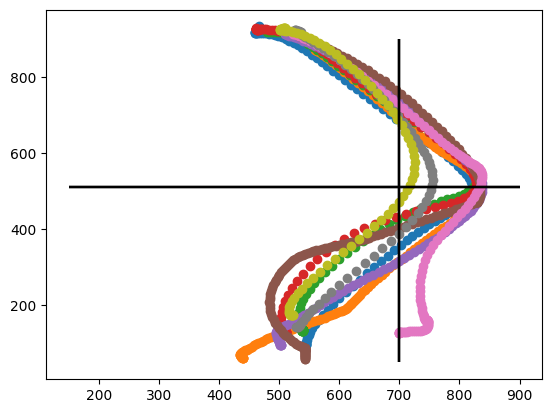

In [15]:
def select_similar_homings(info):
    """
    
    -- Similar time periods
    -- Similar mouse positions
    -- Similar targets

    Raises:
        NotImplementedError: _description_
    """
    # HARDCORE MODE - we like it rough and tough
    xcoordinate_min = 300
    xcoordinate_max = 700
    ycoordinate_min = 200
    ycoordinate_end_min = 750
    x_middle_chunk_min = 400
    x_middle_chunk_max = 600
    extracted_info = []
    for idx, homing in enumerate(info):
        
        # check if mouse x position is within the range - STARTS FARTS ONLY 
        start_x = homing["mouse_x_position"][0]
        start_y = homing["mouse_y_position"][0]
        
        # Starts in a similar space
        if start_x > xcoordinate_min and start_x < xcoordinate_max and start_y < ycoordinate_min:
            
            #Ends in a similar space
            if homing["mouse_y_position"][-1] > ycoordinate_end_min:
                
                # middle of frames is in a similar space
                middle_x = homing["mouse_x_position"][int(len(homing) / 2)]
                if middle_x < x_middle_chunk_min or middle_x > x_middle_chunk_max:
                    # plt.scatter(homing["mouse_x_position"], homing["mouse_y_position"])
                    # plt.hlines(y=512, xmin=150, xmax=900, color="k")
                    
                    # CHOOSE ONE SIDE
                    if middle_x > 700:
                        plt.scatter(homing["mouse_x_position"], homing["mouse_y_position"])
                        plt.hlines(y=512, xmin=150, xmax=900, color="k")
                        plt.vlines(x=700, ymin=50, ymax=900, color="k")
                    
                    
                        extracted_info.append(homing)
                    
    return extracted_info

extracted_info =  select_similar_homings(info)
print(extracted_info[0])
print(len(extracted_info))

### Extract the predictor


In [36]:
# If hsa is greater than h_bar_north_a, then the index will be positive
# If hsa is less than h_bar_north_a, then the index will be negative
homing_data = {}
max_pred = 0
min_pred = 0
epsilon = 0.01 # For safe devision and numerical stability
for idx, homing in enumerate(extracted_info):
    numerator = np.around((homing["hsa"].to_numpy() - homing["h_bar_north_a"].to_numpy()), decimals=1)
    denominator = np.around((homing["hsa"].to_numpy() + homing["h_bar_north_a"].to_numpy()), decimals=1)
    # predictor = np.divide(numerator, denominator + epsilon)
    predictor = np.where(np.abs(denominator) > 0.01, numerator / denominator, np.nan) # Avoid small devisions all together
    # print how many nans there are per homing
    print(f"In homing {idx} there are this number of nans:", np.sum(np.isnan(predictor)))
    # check there are not more than an abitrary number of nans e.g 10
    assert np.sum(np.isnan(predictor)) < 10, "There are too many nans in the predictor, something is wrong with the data or my postdocs are not doing their job properly"
    current_min_pred = np.min(predictor)
    current_max_pred = np.max(predictor)
    if current_min_pred < min_pred:
        min_pred = current_min_pred
    if current_max_pred > max_pred:
        max_pred = current_max_pred
    new_column = pl.Series("predictor", predictor)
    homing = homing.with_columns(new_column)
    homing_data[idx] = homing
# print("Predictor index can go very high up to 141 why is this?")
# This is because if you have 0.007 for HSA and -1.13 for goal then it would equal around 162 for example
# print(homing_data[2].describe())
print(min_pred, max_pred)
pl.Config.set_tbl_rows(100)
print(homing_data[2])
print(homing_data[1])

In homing 0 there are this number of nans: 1
In homing 1 there are this number of nans: 0
In homing 2 there are this number of nans: 1
In homing 3 there are this number of nans: 1
In homing 4 there are this number of nans: 0
In homing 5 there are this number of nans: 2
In homing 6 there are this number of nans: 0
In homing 7 there are this number of nans: 0
In homing 8 there are this number of nans: 1
-28.5 57.0
shape: (101, 8)
┌────────┬────────────┬────────────┬─────────┬───────────┬──────────────┬──────────────┬───────────┐
│ frames ┆ mouse_x_po ┆ mouse_y_po ┆ bin_idx ┆ hsa       ┆ h_bar_north_ ┆ h_bar_south_ ┆ predictor │
│ ---    ┆ sition     ┆ sition     ┆ ---     ┆ ---       ┆ a            ┆ a            ┆ ---       │
│ i64    ┆ ---        ┆ ---        ┆ i64     ┆ f64       ┆ ---          ┆ ---          ┆ f64       │
│        ┆ f64        ┆ f64        ┆         ┆           ┆ f64          ┆ f64          ┆           │
╞════════╪════════════╪════════════╪═════════╪═══════════╪═════

C:\Users\laurence\AppData\Local\Temp\ipykernel_32596\4088924459.py:11: RuntimeWarning: divide by zero encountered in divide
  predictor = np.where(np.abs(denominator) > 0.01, numerator / denominator, np.nan) # Avoid small devisions all together


### Because the min and max of the index is so large, let's normalise (min -462, max 3395)

In [17]:
# Using the min and max predictor across all homings, create a new column that is a normalised version of the predictor
homing_data_normalised = {}
for idx, homing in enumerate(homing_data.values()):
    predictor = homing["predictor"]
    normalised_predictor = (predictor - min_pred) / (max_pred - min_pred)
    new_column = pl.Series("normalised_predictor", normalised_predictor)
    homing = homing.with_columns(new_column)
    homing_data_normalised[idx] = homing
print(homing_data_normalised)

{0: shape: (109, 9)
┌────────┬────────────┬────────────┬─────────┬─────┬────────────┬────────────┬─────────┬────────────┐
│ frames ┆ mouse_x_po ┆ mouse_y_po ┆ bin_idx ┆ ... ┆ h_bar_nort ┆ h_bar_sout ┆ predict ┆ normalised │
│ ---    ┆ sition     ┆ sition     ┆ ---     ┆     ┆ h_a        ┆ h_a        ┆ or      ┆ _predictor │
│ i64    ┆ ---        ┆ ---        ┆ i64     ┆     ┆ ---        ┆ ---        ┆ ---     ┆ ---        │
│        ┆ f64        ┆ f64        ┆         ┆     ┆ f64        ┆ f64        ┆ f64     ┆ f64        │
╞════════╪════════════╪════════════╪═════════╪═════╪════════════╪════════════╪═════════╪════════════╡
│ 437105 ┆ 545.473205 ┆ 97.314552  ┆ 1       ┆ ... ┆ 2.846737   ┆ -2.29099   ┆ -1106.1 ┆ 0.0        │
│        ┆            ┆            ┆         ┆     ┆            ┆            ┆ 28061   ┆            │
│ 437106 ┆ 545.226088 ┆ 96.851737  ┆ 1       ┆ ... ┆ 2.870676   ┆ -2.267845  ┆ -107.80 ┆ 0.707716   │
│        ┆            ┆            ┆         ┆     ┆          

### Prepare indices for design matrix

In [18]:
# get frames first
big_dic = {}
for bin_idx, bin in enumerate(bins):
    trials = {}
    for trial_idx, trial in enumerate(homing_data):
        # Filter the trial by the bin
        x = homing_data[trial]
        homing_chunk = x.filter(x["bin_idx"] == bin_idx)
        
        if len(homing_chunk) == 0:
            continue
        
        else:
            # trials[trial_idx] = homing_chunk["frames"].to_numpy()
            trials[trial_idx] = homing_chunk.select(["frames", "predictor"])
    big_dic[bin_idx] = trials
print(big_dic.keys())
print(big_dic)
    

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])
{0: {}, 1: {0: shape: (7, 2)
┌────────┬──────────────┐
│ frames ┆ predictor    │
│ ---    ┆ ---          │
│ i64    ┆ f64          │
╞════════╪══════════════╡
│ 437105 ┆ -1106.128061 │
│ 437106 ┆ -107.806544  │
│ 437107 ┆ -55.005247   │
│ 437108 ┆ -35.177949   │
│ 437109 ┆ -24.3661     │
│ 437110 ┆ -17.434465   │
│ 437111 ┆ -12.628602   │
└────────┴──────────────┘, 1: shape: (32, 2)
┌────────┬───────────┐
│ frames ┆ predictor │
│ ---    ┆ ---       │
│ i64    ┆ f64       │
╞════════╪═══════════╡
│ 462615 ┆ -0.140996 │
│ 462616 ┆ -0.141517 │
│ 462617 ┆ -0.142432 │
│ 462618 ┆ -0.143801 │
│ ...    ┆ ...       │
│ 462643 ┆ -0.260314 │
│ 462644 ┆ -0.254004 │
│ 462645 ┆ -0.248137 │
│ 462646 ┆ -0.242818 │
└────────┴───────────┘, 4: shape: (13, 2)
┌────────┬────────────┐
│ frames ┆ predictor  │
│ ---    ┆ ---        │
│ i64    ┆ f64        │
╞════════╪════════════╡
│ 627398 ┆ 0.118725   │
│ 627399 ┆ 0.117794   │
│ 627400 ┆ 0.116226   │
│ 627401 ┆ 0.114079   

# Use the big dic to index into spike cluster matrix and create design matrix

In [19]:
total_trials = len(extracted_info)
total_neurons = frame_by_cluster_matrix.shape[1]
print("total_neurons", total_neurons)
design_matrix = np.zeros((total_trials, total_neurons))
dic_matrix = {} # A matrix containing the design matrix for each spatial bin of the homings
# big_dic.keys is distance chunks i.e seperate models for each distance chunk
# big_dic[0] is all the trials in that distance chunk

print(design_matrix[0].shape)

for homing_chunk, bin in enumerate(bins):
    trials = big_dic[homing_chunk]
    for trial_idx in trials:
        spike_counts = np.zeros(total_neurons)
        frames = big_dic[homing_chunk][trial_idx].select("frames").to_numpy().reshape(-1)
        for frame in frames:
            spike_counts += frame_by_cluster_matrix[frame]
        design_matrix[trial_idx] = spike_counts
    dic_matrix[homing_chunk] = design_matrix
    
print(dic_matrix.keys())
print(dic_matrix[0].shape)
print(dic_matrix[0])

# NOTE
# THis could mean for example if the second trial does not go into that bin, then the neural firing will be all zeros
# either remove this, leave it in, or leave it in and regularize it so it doesn't affefct the model too muich
        
            
            
    #         design_matrix[trial_idx] += frame_by_cluster_matrix[frame]
    # dic_matrix[f"bin_idx{bin}"] = design_matrix
    



total_neurons 148
(148,)
dict_keys([0, 1, 2, 3, 4, 5, 6, 7])
(9, 148)
[[  0. 280. 560. ...   0.   0.   0.]
 [570. 510. 940. ...   0.   0.   0.]
 [100. 290. 330. ...   0.   0.   0.]
 ...
 [ 50. 220. 500. ...   0.   0.   0.]
 [560. 540. 700. ...  30.   0.   0.]
 [ 50. 100. 340. ...   0.   0.   0.]]


## Process the design matrices - Zscore across trials for individual neurons

In [20]:
from scipy import stats

zscore_design_matrix = {}
for key in dic_matrix:
    homing_chunk = dic_matrix[key]
    zscore_chunk = stats.zscore(homing_chunk, axis=0, nan_policy='raise') # Zscore the design matrix across the columns
    assert homing_chunk.shape == zscore_chunk.shape, "The zscored design matrix is not the same shape as the original design matrix"
    # Replace NaNs with 0s
    zscore_chunk = np.nan_to_num(zscore_chunk)
    assert not np.isnan(zscore_chunk).any(), "There are NaNs in the zscored design matrix"
    zscore_design_matrix[key] = zscore_chunk
    

## Now put design matrix that has been zscored into PCA

In [21]:
from sklearn import decomposition

pca_zscore_design_matrix = {}
for key in zscore_design_matrix:
    homing_chunk = zscore_design_matrix[key]
    pca = decomposition.PCA(n_components=10)
    pca_chunk = pca.fit_transform(homing_chunk)
    pca_zscore_design_matrix[key] = pca_chunk

ValueError: n_components=10 must be between 0 and min(n_samples, n_features)=9 with svd_solver='full'

# Check predictor variance

In [ ]:
print(big_dic.keys())
print(big_dic[1][0]) # The first trial in the second distance chunk
for trial in big_dic[1]:
    plt.hist(big_dic[1][trial].select("predictor").to_numpy())